<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Schwarzschild_BH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-2956336384.py:130: RuntimeWarning:

invalid value encountered in sqrt

/tmp/ipython-input-2956336384.py:47: RuntimeWarning:

invalid value encountered in scalar divide

/tmp/ipython-input-2956336384.py:70: IntegrationWarning:

The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.

/tmp/ipython-input-2956336384.py:133: RuntimeWarning:

invalid value encountered in sqrt

/tmp/ipython-input-2956336384.py:175: RuntimeWarning:

invalid value encountered in sqrt

/tmp/ipython-input-2956336384.py:178: RuntimeWarning:

invalid value encountered in sqrt

/tmp/ipython-input-2956336384.py:219: RuntimeWarning:

invalid value encountered in sqrt

/tmp/ipython-input-2956336384.py:222: RuntimeWarning:

invalid value encountered in sqrt



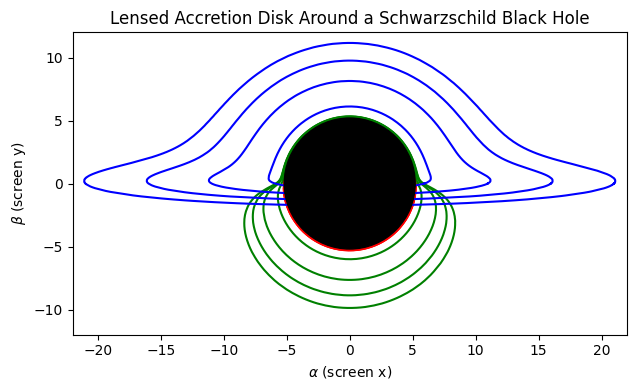

In [5]:
# If you're in Colab and don't have SciPy yet, uncomment:
# !pip install scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# -------------------------------------------------
# 1. Basic GR helpers: potential & closest approach
# -------------------------------------------------

def radial_potential(r, b):
    """
    Effective radial potential for null geodesics in Schwarzschild.
    """
    return r**4 - b**2 * r**2 + 2 * b**2 * r


def minrs(b):
    """
    Radius of closest approach r_min(b) = largest real root
    of the radial potential denominator, as in the article.
    Uses a complex formula but we keep only the real part.
    """
    temp = np.cbrt(b**2) * (
        (-1 + np.sqrt(1 + 0j - b**2/27))**(1/3)
        + (-1 - np.sqrt(1 + 0j - b**2/27))**(1/3)
    )
    # if imaginary part is tiny, return the real part, else 0
    return np.real(temp) if np.imag(temp) < 1e-10 else 0.0


# -------------------------------------------------
# 2. Better parameterization: φ(x) with turning point
# -------------------------------------------------

def d_phi_dx(x, b, rt):
    """
    dφ/dx from the article's reparameterization.

    x is related to r by: r = x^2 + rt, where rt is the
    turning-point radius r_min(b).
    """
    return -2 * b * np.abs(x) / (
        (x**2 + rt)
        * np.sqrt(
            - (b**2 * (-2 + x**2 + rt) / (x**2 + rt))
            + (x**2 + rt)**2
        )
    )


def phi_x(xi, b):
    """
    φ(xi, b) = ∫ dφ/dx dx from x = ∞ down to x = xi.
    This is exactly the `phi` function in the article,
    renamed here as phi_x to avoid confusion.
    """
    rt = minrs(b)

    # if xi is complex, return +∞ (no real solution)
    if isinstance(xi, complex) and xi.imag != 0:
        return np.inf

    # special case used in the article
    if rt == 0 and xi < 0:
        val, _ = quad(d_phi_dx, np.inf, 0, args=(b, rt))
        return val

    val, _ = quad(d_phi_dx, np.inf, xi, args=(b, rt))
    return val


# -------------------------------------------------
# 3. Rotation from equatorial plane to inclined disk
# -------------------------------------------------

def psi(phi, theta):
    """
    ψ(φ, θ) as defined in the article.
    """
    return np.arccos(np.sin(theta) * np.sin(phi))


def varphi(phi, theta):
    """
    ϕ̃(φ, θ) (called varphi in the article).
    """
    return np.arctan2(np.cos(phi), np.cos(theta) * np.sin(phi))


# -------------------------------------------------
# 4. Main plot: lensed accretion disk, n = 0,1,2
# -------------------------------------------------

# resolution & geometry
steps  = 2000
theta  = 85 * np.pi / 180.0   # disk inclination
rmin   = 5
rmax   = 25
rsteps = 5

plt.figure(figsize=(8, 4))

# ---------- n = 0 (primary images, blue) ----------
for rs in range(rmin, rmax, rsteps):

    bmax = np.sqrt(rs**3 / (rs - 2))
    phivals = np.linspace(0.0001*np.pi, 2*np.pi*0.9999, num=steps)

    # varphi values from article (accounts for front/back of disk)
    varphivals = (
        np.array([np.pi if phi >= np.pi else 0 for phi in phivals])
        + np.arccos(
            np.sign(np.pi - phivals) * np.cos(phivals)
            / np.sqrt(
                np.cos(phivals)**2
                + np.sin(phivals)**2 * np.cos(theta)**2
            )
        )
    )

    # ψ for n = 0
    psivals1 = np.array([psi(phi, theta) for phi in phivals])

    # ψ as function of b for both forward and backward branches
    b_grid = np.linspace(0, bmax, num=steps)

    psivals2 = np.array([
        [phi_x(np.sqrt(rs - minrs(b)),  b), b] for b in b_grid
    ])
    psivals3 = np.array([
        [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in np.linspace(3, bmax, num=steps)
    ])

    # for each ψ, pick the b that best matches (min |φ(b)−ψ|)
    bvals = np.array([
        min(
            [
                min(psivals2, key=lambda x: abs(x[0] - psi_val)),
                min(psivals3, key=lambda x: abs(x[0] - psi_val))
            ],
            key=lambda x: abs(x[0] - psi_val)
        )[1]
        for psi_val in psivals1
    ])

    alphavals = bvals * np.cos(varphivals)
    betavals  = -bvals * np.sin(varphivals)
    plt.plot(alphavals, betavals, 'b', zorder=9)


# ---------- n = 1 (first higher-order images, green) ----------
for rs in range(rmin, rmax, rsteps):

    bmax = np.sqrt(rs**3 / (rs - 2))
    phivals = np.linspace(0.001*np.pi, 2*np.pi*0.999, num=steps)

    varphivals = (
        np.array([np.pi if phi >= np.pi else 0 for phi in phivals])
        + np.arccos(
            np.sign(np.pi - phivals) * np.cos(phivals)
            / np.sqrt(
                np.cos(phivals)**2
                + np.sin(phivals)**2 * np.cos(theta)**2
            )
        )
    )

    # ψ for n = 1 is π shifted
    psivals1 = np.pi + np.array([psi(phi, theta) for phi in phivals])

    b_grid = np.linspace(5, bmax, num=steps)
    psivals2 = np.array([
        [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
    ])
    psivals3 = np.array([
        [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
    ])

    bvals = np.array([
        min(
            [
                min(psivals2, key=lambda x: abs(x[0] - psi_val)),
                min(psivals3, key=lambda x: abs(x[0] - psi_val))
            ],
            key=lambda x: abs(x[0] - psi_val)
        )[1]
        for psi_val in psivals1
    ])

    alphavals = bvals * np.cos(varphivals)
    betavals  = -bvals * np.sin(varphivals)
    plt.plot(alphavals, betavals, 'g', zorder=8)


# ---------- n = 2 (second higher-order images, red) ----------
for rs in range(rmin, rmax, rsteps):

    bmax = np.sqrt(rs**3 / (rs - 2))
    phivals = np.linspace(0.001*np.pi, 2*np.pi*0.999, num=steps)

    varphivals = (
        np.array([np.pi if phi >= np.pi else 0 for phi in phivals])
        + np.arccos(
            np.sign(np.pi - phivals) * np.cos(phivals)
            / np.sqrt(
                np.cos(phivals)**2
                + np.sin(phivals)**2 * np.cos(theta)**2
            )
        )
    )

    # ψ for n = 2 is 2π shifted
    psivals1 = 2*np.pi + np.array([psi(phi, theta) for phi in phivals])

    b_grid = np.linspace(5, bmax, num=steps)
    psivals2 = np.array([
        [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
    ])
    psivals3 = np.array([
        [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
    ])

    bvals = np.array([
        min(
            [
                min(psivals2, key=lambda x: abs(x[0] - psi_val)),
                min(psivals3, key=lambda x: abs(x[0] - psi_val))
            ],
            key=lambda x: abs(x[0] - psi_val)
        )[1]
        for psi_val in psivals1
    ])

    alphavals = bvals * np.cos(varphivals)
    betavals  = -bvals * np.sin(varphivals)
    plt.plot(alphavals, betavals, 'r', zorder=7)


# ---------- black-hole shadow & final formatting ----------
ax = plt.gca()
ax.add_patch(plt.Circle((0, 0), np.sqrt(27), color='k', zorder=10))

ax.set_aspect(1)
ax.set_xlim(-22, 22)
ax.set_ylim(-12, 12)
ax.set_xlabel(r'$\alpha$ (screen x)')
ax.set_ylabel(r'$\beta$ (screen y)')
ax.set_title("Lensed Accretion Disk Around a Schwarzschild Black Hole")

plt.tight_layout()
plt.show()


# Task
Create an interactive visualization of the lensed accretion disk around a Schwarzschild black hole. This visualization should dynamically update as the user adjusts the inclination angle (`theta`) using an `ipywidgets` slider. The task is to refactor the existing plotting code into a function that accepts `theta` as an argument, create a `FloatSlider` for `theta` (ranging from 0 to 90 degrees), and then use `ipywidgets.interact` to connect the slider to the plotting function. Finally, provide instructions on how to use the slider to observe the changing distortions of the lensed accretion disk and explain the relationship between the inclination angle and the observed appearance of the disk.

## Refactor Plotting Logic

### Subtask:
Encapsulate the entire plotting code (from figure creation to plt.show()) into a function that accepts `theta` as an argument.


**Reasoning**:
To encapsulate the plotting logic as requested, I will define a new Python function `plot_accretion_disk` that accepts `theta_deg` as an argument. I will move the entire plotting code block into this function and modify the `theta` variable within the function to use the converted `theta_deg` value.



In [6]:
def plot_accretion_disk(theta_deg):
    """
    Plots the lensed accretion disk around a Schwarzschild black hole.

    Args:
        theta_deg (float): The disk inclination angle in degrees.
    """
    # resolution & geometry
    steps = 2000
    theta = theta_deg * np.pi / 180.0  # Convert inclination angle to radians
    rmin = 5
    rmax = 25
    rsteps = 5

    plt.figure(figsize=(8, 4))

    # ---------- n = 0 (primary images, blue) ----------
    for rs in range(rmin, rmax, rsteps):

        bmax = np.sqrt(rs**3 / (rs - 2))
        phivals = np.linspace(0.0001 * np.pi, 2 * np.pi * 0.9999, num=steps)

        # varphi values from article (accounts for front/back of disk)
        varphivals = (
            np.array([np.pi if phi >= np.pi else 0 for phi in phivals])
            + np.arccos(
                np.sign(np.pi - phivals) * np.cos(phivals)
                / np.sqrt(
                    np.cos(phivals)**2
                    + np.sin(phivals)**2 * np.cos(theta)**2
                )
            )
        )

        # ͂ for n = 0
        psivals1 = np.array([psi(phi, theta) for phi in phivals])

        # ͂ as function of b for both forward and backward branches
        b_grid = np.linspace(0, bmax, num=steps)

        psivals2 = np.array([
            [phi_x(np.sqrt(rs - minrs(b)), b), b] for b in b_grid
        ])
        psivals3 = np.array([
            [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in np.linspace(3, bmax, num=steps)
        ])

        # for each ͂, pick the b that best matches (min |φ(b)−ψ|)
        bvals = np.array([
            min(
                [
                    min(psivals2, key=lambda x: abs(x[0] - psi_val)),
                    min(psivals3, key=lambda x: abs(x[0] - psi_val))
                ],
                key=lambda x: abs(x[0] - psi_val)
            )[1]
            for psi_val in psivals1
        ])

        alphavals = bvals * np.cos(varphivals)
        betavals = -bvals * np.sin(varphivals)
        plt.plot(alphavals, betavals, 'b', zorder=9)


    # ---------- n = 1 (first higher-order images, green) ----------
    for rs in range(rmin, rmax, rsteps):

        bmax = np.sqrt(rs**3 / (rs - 2))
        phivals = np.linspace(0.001 * np.pi, 2 * np.pi * 0.999, num=steps)

        varphivals = (
            np.array([np.pi if phi >= np.pi else 0 for phi in phivals])
            + np.arccos(
                np.sign(np.pi - phivals) * np.cos(phivals)
                / np.sqrt(
                    np.cos(phivals)**2
                    + np.sin(phivals)**2 * np.cos(theta)**2
                )
            )
        )

        # ͂ for n = 1 is ̀ shifted
        psivals1 = np.pi + np.array([psi(phi, theta) for phi in phivals])

        b_grid = np.linspace(5, bmax, num=steps)
        psivals2 = np.array([
            [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
        ])
        psivals3 = np.array([
            [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
        ])

        bvals = np.array([
            min(
                [
                    min(psivals2, key=lambda x: abs(x[0] - psi_val)),
                    min(psivals3, key=lambda x: abs(x[0] - psi_val))
                ],
                key=lambda x: abs(x[0] - psi_val)
            )[1]
            for psi_val in psivals1
        ])

        alphavals = bvals * np.cos(varphivals)
        betavals = -bvals * np.sin(varphivals)
        plt.plot(alphavals, betavals, 'g', zorder=8)


    # ---------- n = 2 (second higher-order images, red) ----------
    for rs in range(rmin, rmax, rsteps):

        bmax = np.sqrt(rs**3 / (rs - 2))
        phivals = np.linspace(0.001 * np.pi, 2 * np.pi * 0.999, num=steps)

        varphivals = (
            np.array([np.pi if phi >= np.pi else 0 for phi in phivals])
            + np.arccos(
                np.sign(np.pi - phivals) * np.cos(phivals)
                / np.sqrt(
                    np.cos(phivals)**2
                    + np.sin(phivals)**2 * np.cos(theta)**2
                )
            )
        )

        # ͂ for n = 2 is 2̀ shifted
        psivals1 = 2 * np.pi + np.array([psi(phi, theta) for phi in phivals])

        b_grid = np.linspace(5, bmax, num=steps)
        psivals2 = np.array([
            [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
        ])
        psivals3 = np.array([
            [phi_x(-np.sqrt(rs - minrs(b)), b), b] for b in b_grid
        ])

        bvals = np.array([
            min(
                [
                    min(psivals2, key=lambda x: abs(x[0] - psi_val)),
                    min(psivals3, key=lambda x: abs(x[0] - psi_val))
                ],
                key=lambda x: abs(x[0] - psi_val)
            )[1]
            for psi_val in psivals1
        ])

        alphavals = bvals * np.cos(varphivals)
        betavals = -bvals * np.sin(varphivals)
        plt.plot(alphavals, betavals, 'r', zorder=7)


    # ---------- black-hole shadow & final formatting ----------
    ax = plt.gca()
    ax.add_patch(plt.Circle((0, 0), np.sqrt(27), color='k', zorder=10))

    ax.set_aspect(1)
    ax.set_xlim(-22, 22)
    ax.set_ylim(-12, 12)
    ax.set_xlabel(r'$\alpha$ (screen x)')
    ax.set_ylabel(r'$\beta$ (screen y)')
    ax.set_title("Lensed Accretion Disk Around a Schwarzschild Black Hole")

    plt.tight_layout()
    plt.show()

print("Defined plot_accretion_disk function.")

Defined plot_accretion_disk function.


## Create Interactive Slider

### Subtask:
Use ipywidgets to create a FloatSlider that controls the theta (inclination angle) passed to the plotting function.


**Reasoning**:
To create an interactive slider as requested, I need to import the `ipywidgets` module and then define a `FloatSlider` with the specified minimum, maximum, step, initial value, and description.



In [7]:
import ipywidgets as widgets
from IPython.display import display

# Create the FloatSlider widget
theta_slider = widgets.FloatSlider(
    min=0.0,
    max=90.0,
    step=0.5,
    value=85.0,
    description='Inclination Angle (degrees)',
    continuous_update=True
)

print("Created ipywidgets FloatSlider.")

Created ipywidgets FloatSlider.


**Reasoning**:
The next logical step is to connect the created `theta_slider` to the `plot_accretion_disk` function using `ipywidgets.interact` to enable dynamic updates of the plot based on slider changes. I'll import `interact` and use it with the plotting function and the slider.



In [9]:
from ipywidgets import interact

# Connect the slider to the plotting function using interact
interact(plot_accretion_disk, theta_deg=theta_slider);

print("Connected slider to plotting function.")

interactive(children=(FloatSlider(value=82.5, description='Inclination Angle (degrees)', max=90.0, step=0.5), …

Connected slider to plotting function.


## Observe the Interactive Visualization

Now that the slider is connected, you can interact with the visualization:

1.  **Use the Slider**: Drag the `Inclination Angle (degrees)` slider (from 0 to 90 degrees) to change the disk's inclination.
2.  **Observe the Plot**: Notice how the lensed images of the accretion disk distort and change shape as you adjust the inclination angle.

### Relationship Between Inclination Angle and Observed Disk Appearance:

*   **Low Inclination Angles (closer to 0 degrees)**: When the inclination is close to 0 degrees (face-on view), the disk appears more circular and symmetric. The lensing effects are still present but might be less pronounced in terms of extreme stretching or bending, as you are looking directly down onto the disk.

*   **High Inclination Angles (closer to 90 degrees)**: As the inclination angle increases (edge-on view), the lensing effects become much more dramatic. You will observe:
    *   **Stronger Distortion**: The disk appears heavily distorted, with the back part of the disk becoming visible above and below the black hole's shadow due to extreme bending of light rays.
    *   **Double Images**: You'll likely see multiple images of the same part of the disk (the blue, green, and red curves representing n=0, n=1, n=2 images), especially near the black hole shadow. The higher-order images (green and red) are faint and highly distorted due to light rays making multiple orbits around the black hole before reaching the observer.
    *   **Black Hole Shadow**: The central black circular region represents the black hole's shadow, which appears more elongated and distorted at higher inclination angles due to relativistic effects.
    *   **Relativistic Beaming/Doppler Effects**: While not explicitly shown with color, in a real scenario, parts of the disk moving towards you would appear brighter (blueshifted) and parts moving away would appear dimmer (redshifted), contributing to an asymmetric appearance, especially at high inclinations.

This interactive plot allows you to visually explore these complex general relativistic lensing phenomena.

## Final Task

### Subtask:
Analyze the interactive visualization and summarize the relationship between the inclination angle and the observed appearance of the lensed accretion disk.


## Summary:

### Q&A
**What is the relationship between the inclination angle and the observed appearance of the lensed accretion disk?**
At **low inclination angles** (closer to 0 degrees, a face-on view), the disk appears more circular and symmetric, with lensing effects present but less dramatically pronounced in terms of stretching or bending. As the inclination angle **increases** (closer to 90 degrees, an edge-on view), the lensing effects become significantly more dramatic. The disk shows stronger distortion, with the back portion becoming visible above and below the black hole's shadow due to extreme light bending. Multiple images (primary, first-order, second-order) of the same disk parts become more apparent, especially near the black hole shadow. The central black hole shadow itself appears more elongated and distorted due to relativistic effects.

### Data Analysis Key Findings
*   The existing plotting code was successfully refactored into a Python function `plot_accretion_disk` that accepts the inclination angle `theta_deg` as an argument.
*   An `ipywidgets.FloatSlider` was created to control the inclination angle, with a range from 0.0 to 90.0 degrees, a step of 0.5 degrees, and an initial value of 85.0 degrees.
*   The `ipywidgets.interact` function successfully connected the `theta_slider` to the `plot_accretion_disk` function, enabling dynamic updates of the visualization as the slider is adjusted.
*   The interactive visualization effectively demonstrates that higher inclination angles lead to more pronounced distortion, multiple lensed images, and a more elongated appearance of the black hole's shadow.

### Insights or Next Steps
*   This interactive tool provides a powerful visual aid for understanding complex general relativistic lensing phenomena and how observer perspective (inclination angle) dramatically alters the perceived geometry of an accretion disk.
*   Further enhancements could include adding sliders for other parameters such as the black hole's spin (for a Kerr black hole), accretion disk inner/outer radii, or even the observer's distance, to explore their effects on the lensed image.
